In [ ]:
# install packages
%pip install networkx pandas numpy matplotlib

# 01. Graph Theory + Matrices

Learning outcomes:
1. Represent networks in graph-theoretic language
2. Identify paths, walks, trails, and components
3. Formulate networks in matrix terms
4. Compute and interpret adjacency-matrix multiplication

**How to use this exercise:** Run cells in order from the top. Where you see **Exercise** or `# YOUR CODE HERE`, complete the code or answer in your own words. Answer the **Question(s)** in the markdown cells below each.

## Chapter 1 Bridge: What Is a Social Network?

Before matrix algebra, define a network as:
- **Nodes (actors):** people, groups, organizations
- **Ties (relations):** friendship, advice, communication, flows, co-membership
- **Attributes:** node properties (e.g., age, platform, account type)

In graph-theory terms: a **graph** is made of **nodes** (vertices) and **edges** (connections). For directed graphs, each edge is an ordered pair (source → target).

Key idea: position in the network can create constraints and opportunities.

## Levels of Analysis (Dyad, Node, Network)

- **Dyad level:** pair of actors (A-B tie exists?)
- **Node level:** actor properties from ties (degree, centrality)
- **Network level:** whole-graph properties (density, components, fragmentation)

**Working with datasets:** In practice, network data often comes as a table with two columns (e.g. *From* / *To* or *source* / *target*). You build a graph with `nx.from_pandas_edgelist(df, source='...', target='...')`. In this notebook we use a small hand-built graph; in **notebook 02** we use a CSV and that same pattern.

In [1]:
# Tiny example to map levels of analysis
import pandas as pd

toy_edges = pd.DataFrame({
    'source': ['A','A','B','C','D'],
    'target': ['B','C','C','D','E'],
    'tie_type': ['advice','friendship','advice','friendship','advice']
})

# Dyad variable: tie exists (binary)
toy_edges['tie_exists'] = 1

print('Dyad-level rows (edge list):')
display(toy_edges)
print('Node-level candidate: degree (computed later)')
print('Network-level candidate: number of components (computed later)')

Dyad-level rows (edge list):


,source,target,tie_type,tie_exists
0,A,B,advice,1
1,A,C,friendship,1
2,B,C,advice,1
3,C,D,friendship,1
4,D,E,advice,1


Node-level candidate: degree (computed later)
Network-level candidate: number of components (computed later)


## Tie Types from Chapter 1

You can model ties as:
- **Relational states:** friendship, trust, kinship
- **Relational events:** messages sent, transactions, co-attendance
- **Flows:** information, money, resources

In practice: repeated events are often used as evidence for relational states.

## 1) Setup

In [ ]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (7, 5)

## 2) Make a Tiny Directed Graph

**Goal:** Build a small directed graph so we can inspect it step by step. We define it as **G(V, E)** where **V** = set of nodes and **E** = set of edges (ordered pairs: source → target). Below we create the graph from lists; the same idea applies when building from a CSV with `nx.from_pandas_edgelist`.

In [7]:
# 1) Define nodes and edges (ordered pairs: source → target)
nodes = ['A', 'B', 'C', 'D', 'E']
edges = [('A', 'B'), ('B', 'C'), ('C', 'D'), ('D', 'A'), ('D', 'E')]

# 2) Build the directed graph
G = nx.DiGraph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)

# 3) Inspect: one-line summary (like nx.info) and list of nodes/edges
print(G)
print('Vertices =', list(G.nodes()))
print('Edges =', list(G.edges()))

DiGraph with 5 nodes and 5 edges
Vertices = ['A', 'B', 'C', 'D', 'E']
Edges = [('A', 'B'), ('B', 'C'), ('C', 'D'), ('D', 'A'), ('D', 'E')]


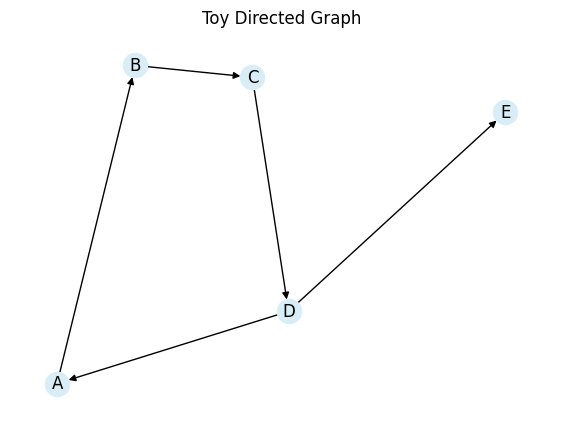

In [8]:
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx(G, pos=pos, with_labels=True, node_color='#d9edf7', arrows=True)
plt.title('Toy Directed Graph')
plt.axis('off')
plt.show()

**Exercise (optional):** How many edges are there? What is the out-degree of D? (You can answer after running the degree cell below, or try from the graph.)

## 3) Adjacency and Degree

- Two nodes are adjacent if there is an edge between them.
- In directed graphs, use in-degree and out-degree.

In [9]:
print('Out-degree:')
print(dict(G.out_degree()))

print('In-degree:')
print(dict(G.in_degree()))

Out-degree:
{'A': 1, 'B': 1, 'C': 1, 'D': 2, 'E': 0}
In-degree:
{'A': 1, 'B': 1, 'C': 1, 'D': 1, 'E': 1}


**Question(s):** Which node has no outgoing edges? Which has the most outgoing edges? *Answer in one sentence each below.*

## 4) Walk, Trail, Path (check examples)

- Walk: can repeat edges and nodes
- Trail: cannot repeat edges
- Path: cannot repeat nodes

In [10]:
# Different kinds of node sequences on G (edges: A→B, B→C, C→D, D→A, D→E)
examples = [
    ('invalid (no A→C)', ['A', 'C']),
    ('walk only (repeats edge & node)', ['A', 'B', 'C', 'D', 'A', 'B']),
    ('trail, not path (cycle, distinct edges)', ['A', 'B', 'C', 'D', 'A']),
    ('path (short)', ['A', 'B', 'C', 'D']),
    ('path (long)', ['A', 'B', 'C', 'D', 'E']),
    ('single node', ['D']),
    ('two-node path', ['D', 'E']),
]


In [11]:
# Exercise: implement is_walk, is_trail, is_path (hints in comments). Replace the raise with your code.
def edge_sequence(seq):
    return list(zip(seq[:-1], seq[1:]))

# Walk: every consecutive pair must be an edge in G; need at least 2 nodes.
def is_walk(G, seq):
    return len(seq) >= 2 and all(G.has_edge(u, v) for u, v in edge_sequence(seq))

# Trail: walk with no repeated edge (use edge_sequence; compare len(es) and len(set(es))).
def is_trail(G, seq):
    es = edge_sequence(seq)
    return is_walk(G, seq) and len(es) == len(set(es))

# Path: walk with no repeated node (compare len(seq) and len(set(seq))).
def is_path(G, seq):
    return is_walk(G, seq) and len(seq) == len(set(seq))

for name, seq in examples:
    es = edge_sequence(seq)
    w, tr, p = is_walk(G, seq), is_trail(G, seq), is_path(G, seq)
    print(f"{name}:")
    print(f"  seq = {seq}" + (f"  edges = {es}" if es else "  (no edges)"))
    print(f"  walk={w}, trail={tr}, path={p}")
    print()

invalid (no A→C):
  seq = ['A', 'C']  edges = [('A', 'C')]
  walk=False, trail=False, path=False

walk only (repeats edge & node):
  seq = ['A', 'B', 'C', 'D', 'A', 'B']  edges = [('A', 'B'), ('B', 'C'), ('C', 'D'), ('D', 'A'), ('A', 'B')]
  walk=True, trail=False, path=False

trail, not path (cycle, distinct edges):
  seq = ['A', 'B', 'C', 'D', 'A']  edges = [('A', 'B'), ('B', 'C'), ('C', 'D'), ('D', 'A')]
  walk=True, trail=True, path=False

path (short):
  seq = ['A', 'B', 'C', 'D']  edges = [('A', 'B'), ('B', 'C'), ('C', 'D')]
  walk=True, trail=True, path=True

path (long):
  seq = ['A', 'B', 'C', 'D', 'E']  edges = [('A', 'B'), ('B', 'C'), ('C', 'D'), ('D', 'E')]
  walk=True, trail=True, path=True

single node:
  seq = ['D']  (no edges)
  walk=False, trail=False, path=False

two-node path:
  seq = ['D', 'E']  edges = [('D', 'E')]
  walk=True, trail=True, path=True



In [12]:
# Self-check (run after implementing the functions above)
assert is_walk(G, ['A','B','C','D','A','B']) and not is_trail(G, ['A','B','C','D','A','B'])
assert is_trail(G, ['A','B','C','D','A']) and not is_path(G, ['A','B','C','D','A'])
assert is_path(G, ['A','B','C','D']) and is_path(G, ['D','E'])
print('Self-check passed.')

Self-check passed.


**Exercise (optional):** Add one new sequence to `examples` that is a trail but not a path, and run the cell again.

## 5) Components (strong vs weak)

In directed graphs:
- Strong components respect direction
- Weak components ignore direction

In [13]:
strong = list(nx.strongly_connected_components(G))
weak = list(nx.weakly_connected_components(G))
print('Strong components:', strong)
print('Weak components:', weak)

Strong components: [{'E'}, {'A', 'C', 'D', 'B'}]
Weak components: [{'B', 'C', 'E', 'D', 'A'}]


**Question(s):** Why are there two strong components but one weak component? Why is E in its own strong component? *Answer in 2–3 sentences below.*

## 6) Adjacency Matrix

In [14]:
A = nx.to_pandas_adjacency(G, nodelist=nodes, dtype=int)
A

,A,B,C,D,E
A,0,1,0,0,0
B,0,0,1,0,0
C,0,0,0,1,0
D,1,0,0,0,1
E,0,0,0,0,0


**Question(s):** In one sentence: what does the row of node D in A represent? What does the column of node C represent? *Answer below.*


## 7) Matrix Multiplication: `A^2` and `A^3`

Interpretation:
- Entry `(i, j)` in `A^2` = number of length-2 walks from `i` to `j`
- Entry `(i, j)` in `A^3` = number of length-3 walks from `i` to `j`

**Exercise:** Without using code first: list by hand all length-2 walks from A to C. Then run the cells below and check the entry (A,C) in A². Do the same for length-3 walks from A to D and the entry (A,D) in A³. *Write your hand list in this cell (or the one below).*

In [15]:
A_np = A.values
A2 = A_np @ A_np
A3 = A2 @ A_np

A2_df = pd.DataFrame(A2, index=nodes, columns=nodes)
A3_df = pd.DataFrame(A3, index=nodes, columns=nodes)

print('A^2:')
display(A2_df)
print('A^3:')
display(A3_df)

A^2:


,A,B,C,D,E
A,0,0,1,0,0
B,0,0,0,1,0
C,1,0,0,0,1
D,0,1,0,0,0
E,0,0,0,0,0


A^3:


,A,B,C,D,E
A,0,0,0,1,0
B,1,0,0,0,1
C,0,1,0,0,0
D,0,0,1,0,0
E,0,0,0,0,0


In [16]:
print('Example interpretation:')
print('Number of length-2 walks from A to C =', A2_df.loc['A','C'])
print('Number of length-3 walks from A to D =', A3_df.loc['A','D'])

Example interpretation:
Number of length-2 walks from A to C = 1
Number of length-3 walks from A to D = 1


## 8) Edge List ↔ Adjacency Matrix

**Goal:** The same network can be stored as an **edge list** (rows = edges) or an **adjacency matrix** (rows/columns = nodes). Most tools and datasets use edge lists; matrices are handy for algebra (e.g. powers of A). Many real-world datasets are shared as CSV edge lists (e.g. [SNAP](https://snap.stanford.edu/data/), [Network Repository](https://networkrepository.com/)); load with pandas and build the graph with `nx.from_pandas_edgelist`.

In [17]:
edge_list_df = pd.DataFrame(edges, columns=['source','target'])
edge_list_df['weight'] = 1
edge_list_df

,source,target,weight
0,A,B,1
1,B,C,1
2,C,D,1
3,D,A,1
4,D,E,1


**Exercise:** From the existing edge list `edges` (or `edge_list_df`), build the adjacency matrix **without** using `nx.to_pandas_adjacency`. Use pandas or numpy (e.g. pivot or a loop) and compare with `A`.

In [ ]:
# Build adjacency matrix from edge list (no networkx). Compare with A.
# YOUR CODE HERE
# A_from_edges = ...
# (A_from_edges == A.values).all()  # or similar check

In [18]:
# save edge list and adjacency matrix
edge_list_df.to_csv('simple_edge_list.csv', index=False)
A.to_csv('simple_adjacency_matrix.csv')
